In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
import os

# If the kernel started from the plots/ subdirectory, move up to the base directory.
if os.path.basename(os.getcwd()) == 'plots':
    os.chdir('..')
#print('Working directory:', os.getcwd())

from coffea.util import load
from plots import hep_plot as hplot
from plots.hep_plot import CMS_COLORS
import hist

hplot.setup("2024")

In [24]:
output = load('./outputs/dy/TTbar_2024inclusive.coffea')

In [25]:
output.keys()

dict_keys(['ttbarmass', 'mtt_unwgt', 'mtt_vs_mt', 'numerator', 'denominator', 'jetmass', 'jetmsd', 'jetdy', 'jetmass1', 'jetmsd1', 'dR_min_jet2', 'gen_mt', 'gen_mttbar', 'jet0_gen_dr', 'jet1_gen_dr', 'jet_mass_resolution', 'gen_jetmsd_reco_jetmsd', 'ht', 'cutflow', 'weights', 'systematics', 'event_list', 'truthstudy', 'analysisCategories'])

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7fb2afc4a570>, cbar=<matplotlib.colorbar.Colorbar object at 0x7fb2ae01bb90>, text=[])

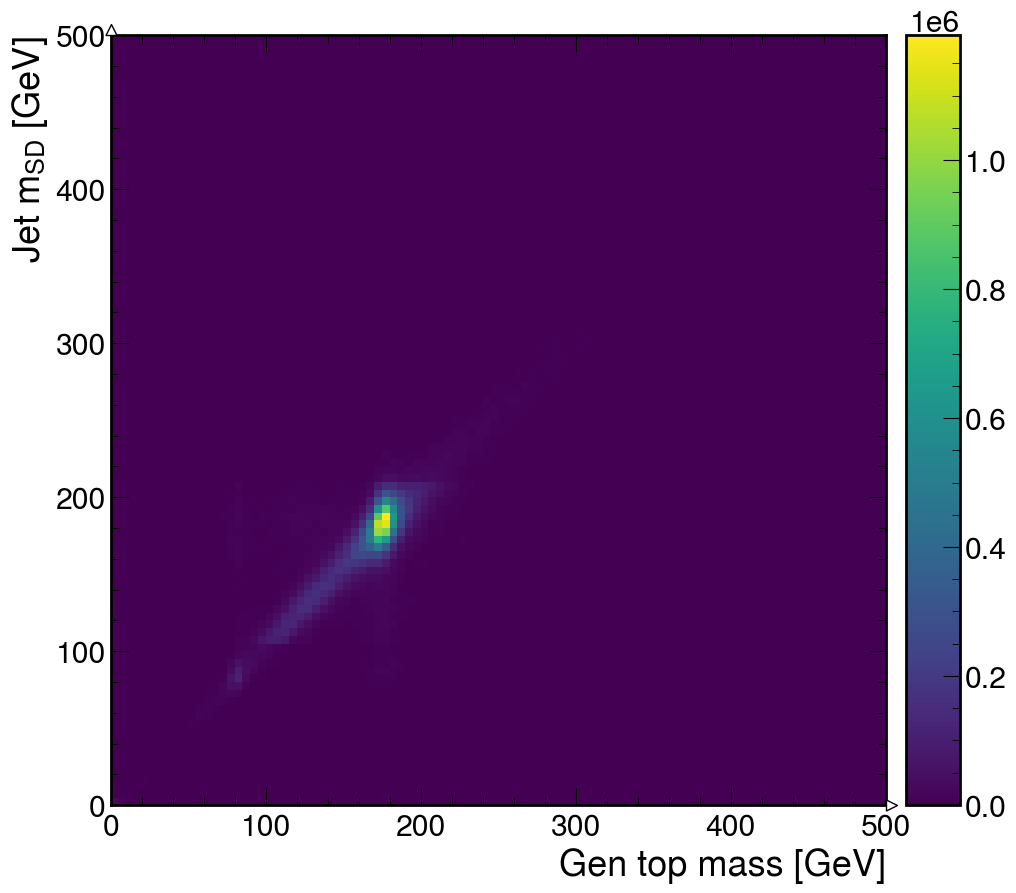

In [26]:
output['gen_jetmsd_reco_jetmsd']['nominal', ...].project('mass', 'jetmass').plot()

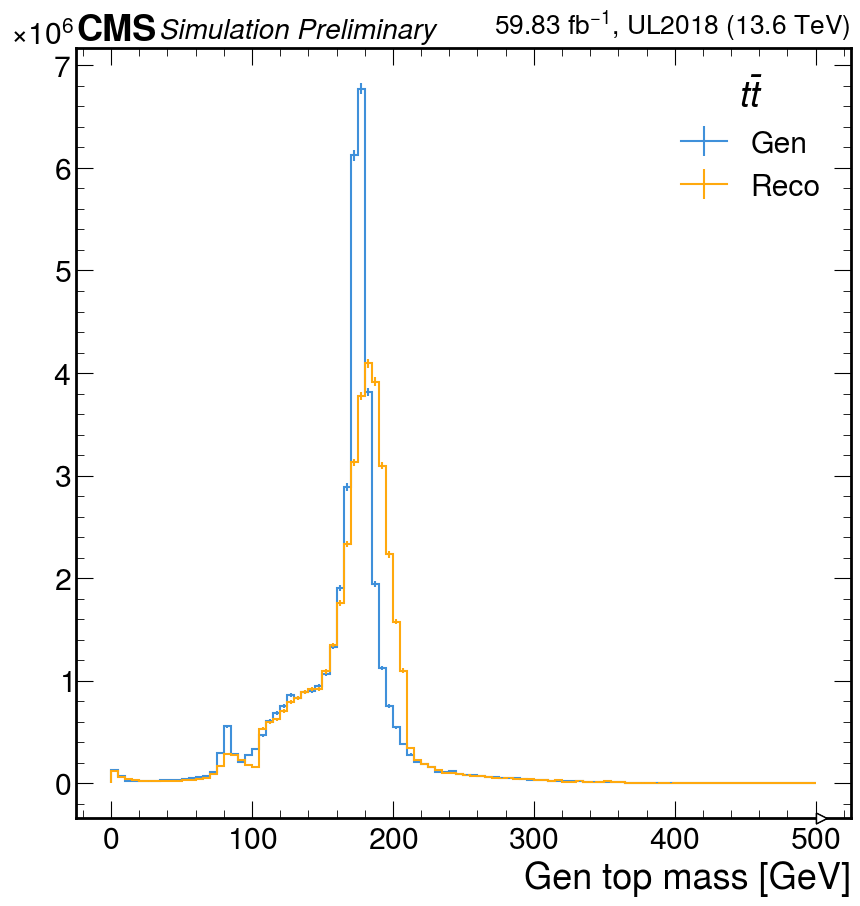

In [31]:
hplot.plot1dList(output, 'gen_jetmsd_reco_jetmsd', ['mass', 'jetmass'], labels = ['Gen', 'Reco'], dataset = r"$t\bar{t}$")
hplot.quick_label(loc = 0)

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f528436c080>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

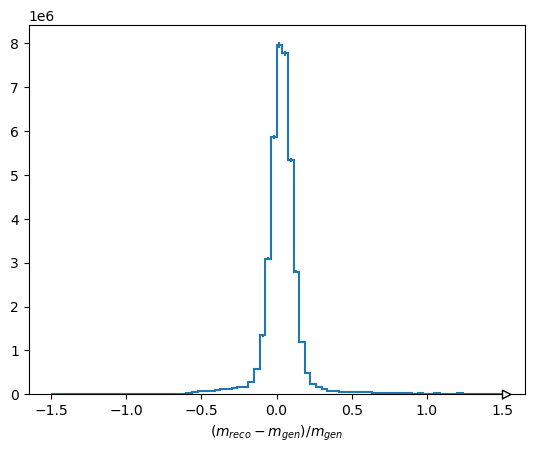

In [26]:
output['jet_mass_resolution']['nominal', ...].project('massres').plot()

In [19]:
output['dR_min_jet2']

Hist(
  StrCategory(['nominal', 'jesDown', 'jesUp', 'jerDown', 'jerUp', 'pileupDown', 'pileupUp', 'pdfDown', 'pdfUp', 'q2Down', 'q2Up', 'ttag_pt1Down', 'ttag_pt1Up'], name='systematic'),
  IntCategory([0, 1, 2, 3], name='anacat', label='Analysis Category'),
  Regular(50, 0, 5, name='dr', label='$\\Delta R$'),
  Regular(92, 800, 10000, name='ttbarmass', label='$m_{t\\bar{t}}$ [GeV]'),
  storage=Weight()) # Sum: WeightedSum(value=1.76831e+08, variance=6.81353e+10) (WeightedSum(value=1.76864e+08, variance=6.81514e+10) with flow)

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f5275d57470>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

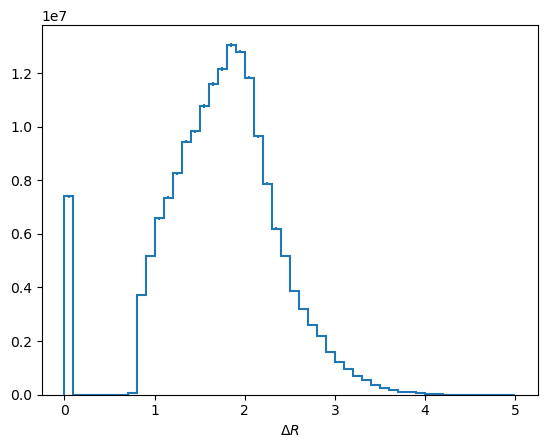

In [20]:
output['dR_min_jet2']['nominal', ...].project('dr').plot()

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7f5276b6e780>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f5277985eb0>, text=[])

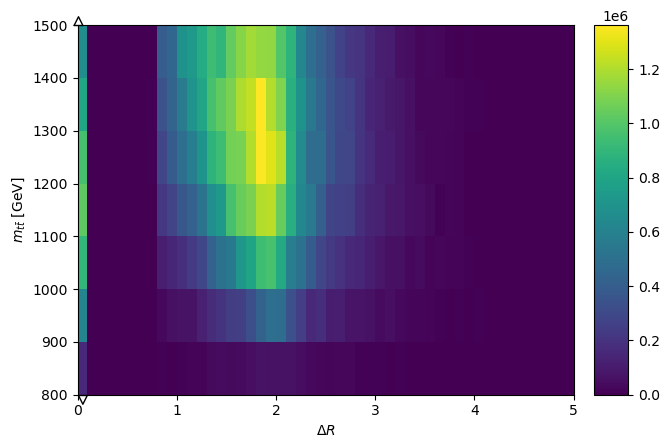

In [18]:
output['dR_min_jet2'].project('dr', 'ttbarmass')[:, hist.loc(800):hist.loc(1500)].plot()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f5279986ed0>, errorbar=<ErrorbarContainer object of 3 artists>, legend_artist=<ErrorbarContainer object of 3 artists>)]

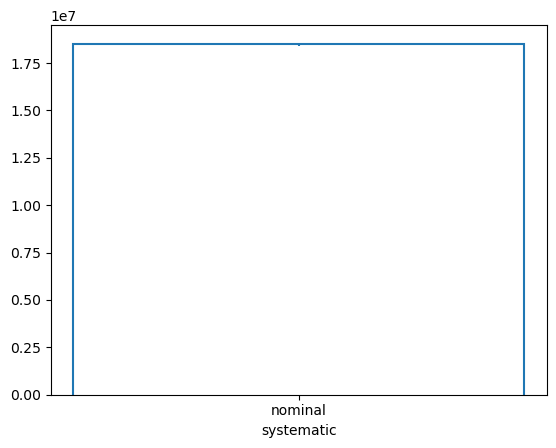

In [8]:
output['jetmsd'].project('systematic').plot()

In [9]:
output['ttbarmass'].project('systematic')

Hist(StrCategory(['nominal'], name='systematic'), storage=Weight()) # Sum: WeightedSum(value=1.84966e+07, variance=5.60144e+09)

In [10]:
output = load("./outputs/dy/ZPrime4000_1_2024.coffea")

In [11]:
output.keys()

dict_keys(['ttbarmass', 'mtt_unwgt', 'mtt_vs_mt', 'numerator', 'denominator', 'jetmass', 'jetmsd', 'jetdy', 'jetmass1', 'jetmsd1', 'dR_min_jet2', 'gen_mt', 'gen_mttbar', 'jet0_gen_dr', 'jet1_gen_dr', 'jet_mass_resolution', 'gen_jetmsd_reco_jetmsd', 'ht', 'cutflow', 'weights', 'systematics', 'event_list', 'truthstudy', 'analysisCategories'])

In [12]:
output['jetmsd1']

Hist(
  StrCategory(['nominal', 'jesDown', 'jesUp', 'pileupDown', 'pileupUp', 'pdfDown', 'pdfUp', 'q2Down', 'q2Up', 'ttag_pt1Down', 'ttag_pt1Up'], name='systematic'),
  IntCategory([0, 1, 2, 3], name='anacat', label='Analysis Category'),
  Regular(20, 0, 500, name='jetmass', label='Jet $m_{SD}$ [GeV]'),
  storage=Weight()) # Sum: WeightedSum(value=0, variance=0)

In [30]:
import matplotlib.pyplot as plt
hplot.setup(era = 2024)
output['ttbarmass'].project('systematic', 'jetmass').plot()
hplot.quick_label()
plt.xlim(0, 2000)

ValueError: The axis name jetmass could not be found

In [31]:
import mplhep as mh
import matplotlib.pyplot as plt

def plot_systematic(syst_name, h_key, hist_axis, xlabel=''):
    """Plot nominal vs Up/Down variation for a given systematic."""
    hplot.setup(era=2024)
    h_nom  = output[h_key].project('systematic', hist_axis)['nominal', ...]
    h_up   = output[h_key].project('systematic', hist_axis)[f'{syst_name}Up', ...]
    h_down = output[h_key].project('systematic', hist_axis)[f'{syst_name}Down', ...]

    fig, (ax_main, ax_comp) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    h_nom.plot( density=False, ax=ax_main, color='k',           label='Nominal')
    h_up.plot(  density=False, ax=ax_main, color=CMS_COLORS[0], label=f'{syst_name} Up')
    h_down.plot(density=False, ax=ax_main, color=CMS_COLORS[4], label=f'{syst_name} Down')
    ax_main.legend()
    #ax_main.set_title(f'{h_key}  —  {syst_name}')
    hplot.quick_label(data=False, ax=ax_main, xlabel='', ylabel='# Events')

    mh.comp.comparison(
        h_nom, h_up,
        ax=ax_comp, comparison='ratio',
        h1_label='Nominal', h2_label=f'{syst_name} Up',
        color=CMS_COLORS[0],
    )
    mh.comp.comparison(
        h_nom, h_down,
        ax=ax_comp, comparison='ratio',
        h1_label='Nominal', h2_label=f'{syst_name} Down',
        color=CMS_COLORS[4],
        xlabel=xlabel, comparison_ylim=(0, 2),
    )
    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


AttributeError: module 'mplhep' has no attribute 'comp'

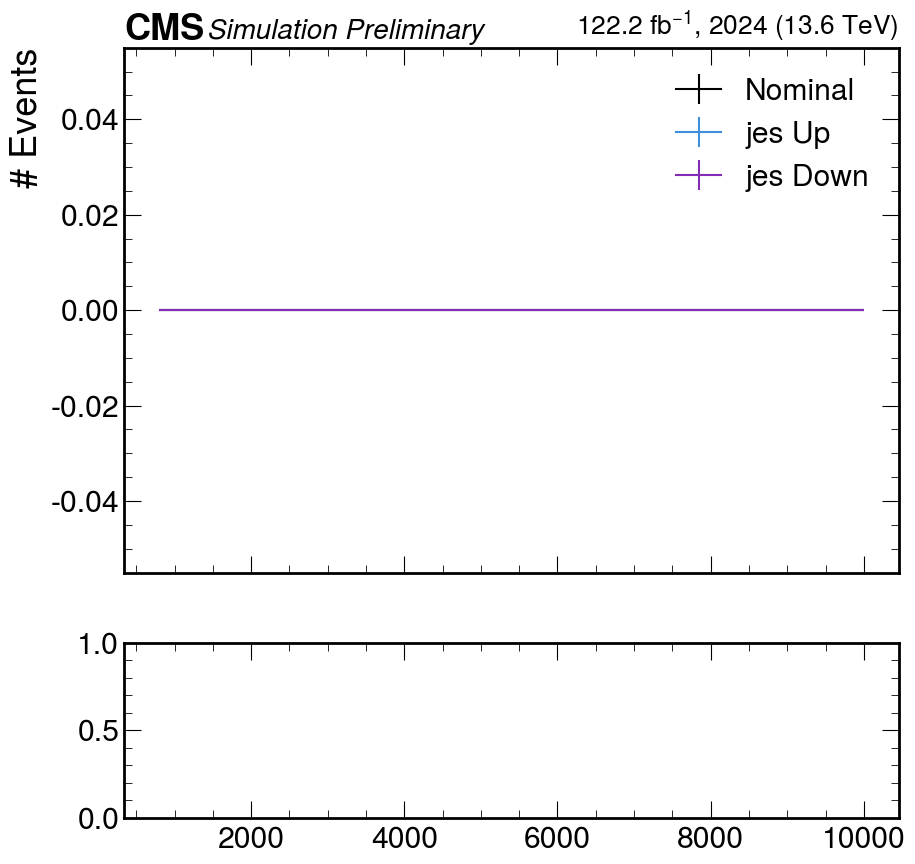

In [34]:
systematics = ['jes', 'pileup', 'pdf', 'q2', 'ttag_pt1']

for syst in systematics:
    plot_systematic(syst, 'ttbarmass', 'ttbarmass', xlabel=r'$m_{t\bar{t}}$ [GeV]')
    plot_systematic(syst, 'jetmsd',    'jetmass',   xlabel=r'Jet $m_{SD}$ [GeV]')


In [33]:
!pip install mplhep